In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [13]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [15]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [16]:
X.shape

(200, 2)

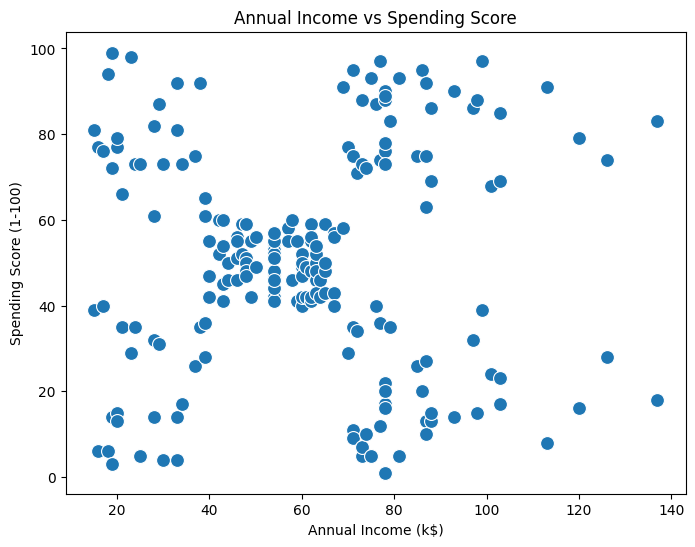

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=100
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [18]:
X_array = X.values.astype(float)

mean = np.mean(X_array, axis=0)
std = np.std(X_array, axis=0)

X_scaled = (X_array - mean) / std

In [19]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [20]:
np.mean(X_scaled, axis=0)

array([-2.13162821e-16, -1.46549439e-16])

In [21]:
np.std(X_scaled, axis=0)

array([1., 1.])

In [22]:
def euclidean_distance(point, centroid):
    return np.sqrt(np.sum((point - centroid) ** 2))

In [23]:
point = np.array([1, 2])
centroid = np.array([4, 6])

distance = euclidean_distance(point, centroid)

print(distance)

5.0


In [24]:
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

In [25]:
np.random.seed(42)

k = 3

centroids = initialize_centroids(X_scaled, k)

print(centroids)

[[-0.02137488  0.06987881]
 [-1.54815205  1.11806095]
 [-1.16645776 -1.7935561 ]]


In [26]:
def assign_clusters(X, centroids):
    clusters = []

    for point in X:
        distances = []

        for centroid in centroids:
            distance = euclidean_distance(point, centroid)
            distances.append(distance)

        cluster = np.argmin(distances)
        clusters.append(cluster)

    return np.array(clusters)

In [27]:
labels = assign_clusters(X_scaled, centroids)

print(labels[:20])

[2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


In [28]:
def update_centroids(X, labels, k):
    new_centroids = []

    for cluster in range(k):

        cluster_points = X[labels == cluster]

        if len(cluster_points) > 0:
            centroid = np.mean(cluster_points, axis=0)
        else:
            centroid = X[np.random.randint(len(X))]

        new_centroids.append(centroid)

    return np.array(new_centroids)

In [29]:
def kmeans(X, k, max_iterations=100):

    centroids = initialize_centroids(X, k)

    for iteration in range(max_iterations):

        # Step 1: Assign points to nearest centroid
        labels = assign_clusters(X, centroids)

        # Step 2: Calculate new centroids
        new_centroids = update_centroids(X, labels, k)

        # Check whether centroids have stopped changing
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

In [30]:
np.random.seed(42)

labels, centroids = kmeans(X_scaled, k=3)

print("Cluster labels:")
print(labels)

print("\nCentroids:")
print(centroids)

Cluster labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0]

Centroids:
[[ 0.99158305  1.23950275]
 [-0.62618966 -0.01439238]
 [ 1.00919971 -1.22553537]]


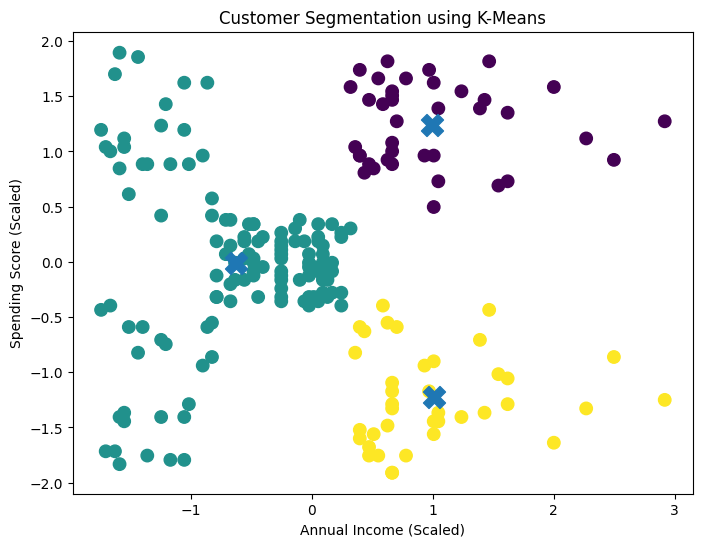

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=80
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()